# 📈 Stock Price Prediction using Machine Learning

### An End-to-End ML Pipeline with Explainability

**Author:** Muhammad Ali Waris Khan  

### 👨‍💻 Internship Project – AI/ML Engineering  
## 📌 Project Overview

This project aims to predict the next day's closing price of a stock using historical market data. Unlike traditional regression problems, stock price prediction is inherently time-dependent and requires careful handling of temporal relationships to avoid data leakage.

We use Tesla (TSLA) stock data and apply machine learning models along with feature engineering techniques such as lag features and rolling statistics.

---

## 🎯 Objectives

- Predict next-day closing price using historical features
- Apply time-series aware data splitting
- Engineer meaningful features (lag, rolling statistics)
- Train and compare multiple regression models
- Evaluate performance using proper regression metrics
- Interpret model behavior using visualizations

---

## ⚠️ Key Challenges

- Stock data is highly volatile and non-stationary
- Risk of data leakage due to temporal dependencies
- Feature engineering is critical for performance

# Problem Statement

The objective of this project is to predict the next day's closing stock price using historical market data. Stock price prediction is a challenging problem due to its stochastic and time-dependent nature.

Unlike traditional regression problems, stock data is inherently sequential, meaning that past values influence future values. Therefore, special care must be taken to avoid data leakage and ensure that temporal order is preserved during model training.

In this project, we aim to:
- Use historical stock data for Tesla (TSLA)
- Perform feature engineering using lagged and rolling features
- Train machine learning models such as Linear Regression and Random Forest
- Evaluate performance using appropriate regression metrics
- Analyze prediction behavior through visualizations

---

# Data Collection

We use the `yfinance` API to retrieve historical stock market data for Tesla (TSLA). The dataset includes:

- Open: Opening price of the stock
- High: Highest price during the day
- Low: Lowest price during the day
- Close: Closing price (target variable)
- Volume: Number of shares traded

The data spans multiple years, allowing the model to learn both short-term and long-term trends.



# 1. 📦 Environment Setup

In [2]:
!pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

# 2. 📥 Data Collection

In [7]:
# Load stock data
ticker = "TSLA"

df = yf.download(ticker, start="2018-01-01", end="2025-01-01")

# Reset index
df.reset_index(inplace=True)

# Display first rows
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000
1,2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500
2,2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500
3,2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000
4,2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000


### Data Cleaning Note

The dataset initially contained a multi-level column index due to how the yfinance API structures its output.

For machine learning workflows, especially when using libraries like scikit-learn, it is essential to have a flat and clean column structure. Multi-index columns can introduce unnecessary complexity and potential bugs during feature engineering and model training.

Therefore, we flattened the column names into a simple, single-level format.

In [8]:
# Flatten multi-level columns
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# Verify
df.head()

,Date,Close,High,Low,Open,Volume
0,2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000
1,2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500
2,2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500
3,2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000
4,2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000


# 3. 🔍 Data Understanding

In [9]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()
df.describe()

Shape: (1761, 6)

Columns:
 Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1761 non-null   datetime64[ns]
 1   Close   1761 non-null   float64       
 2   High    1761 non-null   float64       
 3   Low     1761 non-null   float64       
 4   Open    1761 non-null   float64       
 5   Volume  1761 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 82.7 KB


,Date,Close,High,Low,Open,Volume
count,1761,1761.000000,1761.000000,1761.000000,1761.000000,1.761000e+03
mean,2021-07-01 15:36:17.172061440,158.092595,161.659371,154.358375,158.123470,1.277516e+08
min,2018-01-02 00:00:00,11.931333,12.445333,11.799333,12.073333,2.940180e+07
25%,2019-10-02 00:00:00,23.176001,23.520000,22.814667,23.167334,7.885560e+07
50%,2021-07-01 00:00:00,183.009995,186.440002,179.009995,183.353333,1.048674e+08
75%,2023-03-31 00:00:00,243.133331,248.246674,238.309998,243.240005,1.478910e+08
max,2024-12-31 00:00:00,479.859985,488.540009,457.510010,475.899994,9.140820e+08
std,NaN,112.432886,115.043357,109.763487,112.545980,7.959809e+07


# 4. 📊 Initial Data Visualization

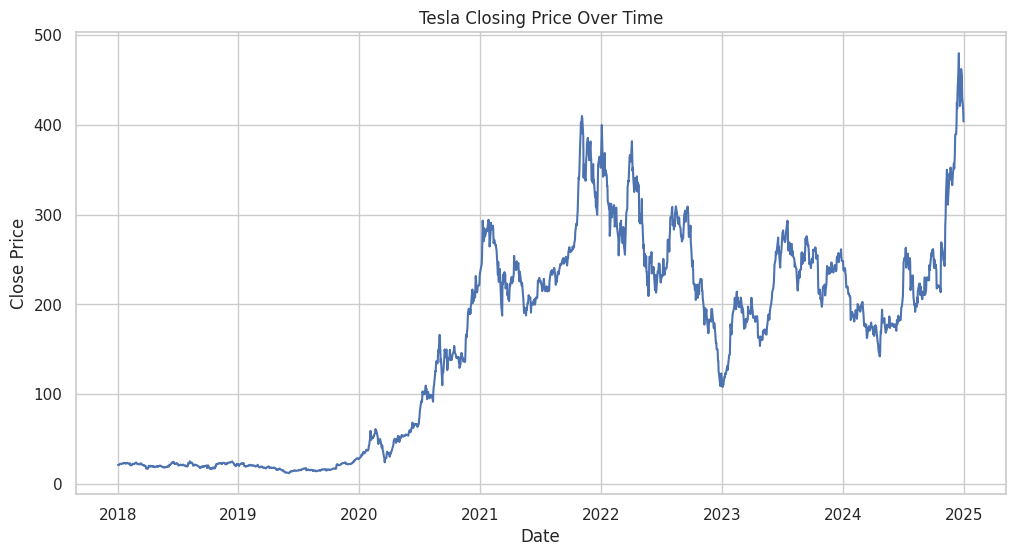

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Tesla Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

### 📌 Interpretation of Stock Price Trend

From the visualization of Tesla's closing price over time, several key observations can be made:

- The stock exhibits significant volatility, with sharp upward and downward movements.
- There is a noticeable long-term upward trend, especially during certain periods.
- The variance of the data changes over time, indicating **non-stationarity**.

### ⚠️ Why This Matters

Non-stationary data violates the assumptions of many traditional machine learning models. This means:

- The model may struggle to generalize if raw values are used directly
- We need to create features that capture temporal patterns (e.g., lag values, rolling averages)

This reinforces the need for **time-aware feature engineering and validation strategies**.

# 5. 🎯 Feature Engineering

In [11]:
# Create target variable: Next day's closing price
df['Target'] = df['Close'].shift(-1)

# Remove last row (it will have NaN target)
df = df.dropna()

df.head()

,Date,Close,High,Low,Open,Volume,Target
0,2018-01-02,21.368668,21.474001,20.733334,20.799999,65283000,21.150000
1,2018-01-03,21.150000,21.683332,21.036667,21.400000,67822500,20.974667
2,2018-01-04,20.974667,21.236668,20.378668,20.858000,149194500,21.105333
3,2018-01-05,21.105333,21.149332,20.799999,21.108000,68868000,22.427334
4,2018-01-08,22.427334,22.468000,21.033333,21.066668,147891000,22.246000


### 🎯 Target Variable Creation

We define the prediction target as the next day's closing price. This is done using a shift operation.

This step is crucial because:

- It transforms the problem into a supervised learning task
- Each row now represents today's features → tomorrow's price
- It ensures the model learns temporal forecasting behavior

In [12]:
# Lag features (previous days' closing prices)
df['Close_Lag1'] = df['Close'].shift(1)
df['Close_Lag2'] = df['Close'].shift(2)
df['Close_Lag3'] = df['Close'].shift(3)

### Lag Features

Lag features allow the model to learn from previous time steps.

We create:
- Close_Lag1 → previous day price
- Close_Lag2 → 2 days ago
- Close_Lag3 → 3 days ago

These features help capture short-term market momentum.

In [13]:
# Rolling mean and volatility
df['Rolling_Mean_5'] = df['Close'].rolling(window=5).mean()
df['Rolling_Std_5'] = df['Close'].rolling(window=5).std()

df['Rolling_Mean_10'] = df['Close'].rolling(window=10).mean()
df['Rolling_Std_10'] = df['Close'].rolling(window=10).std()

### 📊 Rolling Statistics

Rolling features help capture market trends and volatility:

- Rolling Mean → trend direction
- Rolling Std → market volatility

We compute these over 5-day and 10-day windows to capture both short-term and slightly longer-term behavior.

In [14]:
df = df.dropna()

df.head()

,Date,Close,High,Low,Open,Volume,Target,Close_Lag1,Close_Lag2,Close_Lag3,Rolling_Mean_5,Rolling_Std_5,Rolling_Mean_10,Rolling_Std_10
9,2018-01-16,22.670668,23.000000,22.320000,22.502666,97114500,23.143999,22.414667,22.530001,22.320000,22.436267,0.168757,21.920734,0.679719
10,2018-01-17,23.143999,23.266666,22.650000,22.698000,106552500,22.971333,22.670668,22.414667,22.530001,22.615867,0.323001,22.098267,0.747929
11,2018-01-18,22.971333,23.486668,22.916000,23.044666,85287000,23.334667,23.143999,22.670668,22.414667,22.746133,0.304668,22.280400,0.712265
12,2018-01-19,23.334667,23.372667,22.840000,23.000000,73324500,23.437332,22.971333,23.143999,22.670668,22.907067,0.367917,22.516400,0.616033
13,2018-01-22,23.437332,23.855333,23.280001,23.293333,93156000,23.519333,23.334667,22.971333,23.143999,23.111600,0.304551,22.749600,0.438261


### Handling Missing Values

Feature engineering introduces missing values due to lag and rolling operations.

We remove these rows to ensure clean and consistent training data.

In [21]:
# Sort by date (CRITICAL for time series)
df = df.sort_values('Date')

# Define features and target
features = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'Close_Lag1', 'Close_Lag2', 'Close_Lag3',
    'Rolling_Mean_5', 'Rolling_Std_5',
    'Rolling_Mean_10', 'Rolling_Std_10'
]

target = 'Target'

X = df[features]
y = df[target]

### 📌 Feature Selection Strategy

We select a combination of:

#### 🔹 Raw market features:
- Open, High, Low, Close, Volume

#### 🔹 Engineered features:
- Lag features (past prices)
- Rolling mean (trend)
- Rolling standard deviation (volatility)

This combination allows the model to learn both:
- Short-term momentum
- Market trend behavior
- Volatility patterns

The target variable is the next day's closing price.

## 6. ⏳ Time-Based Train-Test Split

### 📌 Why Not Random Split?

In time-series problems like stock prediction, random splitting is incorrect because it allows future data to leak into the training process. This creates unrealistic performance and invalidates the model.

### ✅ Our Approach

We use a chronological split:
- Train set → Older data (past)
- Test set → Newer data (future)

This simulates real-world trading conditions where predictions are always made on unseen future data.

In [22]:
# Define split point (80% train, 20% test)
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1400, 12)
Testing size: (351, 12)


### 📊 Train-Test Split Summary

- Training samples: 1400 (historical data)
- Testing samples: 351 (future unseen data)

This split ensures that the model is trained only on past information and evaluated on future market behavior.

This is essential for realistic performance evaluation in financial prediction tasks.

## 7. Model Training — Linear Regression (Baseline Model)

### 📌 Why Start with Linear Regression?

Before using complex models, we start with a simple baseline model: Linear Regression.

This helps us understand:
- Whether the relationship between features and target is approximately linear
- A performance baseline to compare advanced models against

### ⚠️ Important Concept

If a complex model does not significantly outperform Linear Regression, it may indicate:
- Weak feature engineering
- Overfitting in complex models
- Or that the problem is largely linear in nature

In [23]:
# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

print("Linear Regression training completed.")

Linear Regression training completed.


### 📊 Linear Regression Training Result

The Linear Regression model has been successfully trained on historical stock data.

It learns a weighted linear relationship between:
- Market indicators (Open, High, Low, Close, Volume)
- Engineered features (lags and rolling statistics)

### 📌 Key Insight

Linear models assume a straight-line relationship between input features and output. However, stock markets are often non-linear and noisy, so we expect this model to provide a **reasonable baseline but not highly accurate predictions**.

## 8. Model Training — Random Forest Regressor

### 📌 Why Random Forest?

Stock price movements are influenced by complex, non-linear relationships.

Random Forest is used because:
- It handles non-linearity well
- It is robust to noise
- It reduces overfitting using ensemble learning
- It captures feature interactions automatically

In [24]:
# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


### 📊 Random Forest Training Result

The Random Forest model has been trained successfully.

Unlike Linear Regression, this model:
- Captures non-linear relationships
- Learns complex interactions between features
- Is more robust to noise in stock data

### 📌 Expected Outcome

We expect Random Forest to outperform Linear Regression due to its ability to model complex market behavior patterns.

## 9. 📊 Model Evaluation and Comparison

### 📌 Evaluation Metrics Used

We evaluate models using:

- MAE (Mean Absolute Error): Average prediction error
- RMSE (Root Mean Squared Error): Penalizes large errors
- R² Score: How well the model explains variance

These metrics help us understand both accuracy and stability of predictions.

In [25]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"📊 {name} Performance:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    print("-"*30)

evaluate_model("Linear Regression", y_test, lr_pred)
evaluate_model("Random Forest", y_test, rf_pred)

📊 Linear Regression Performance:
MAE  : 6.4269
RMSE : 9.3083
R2   : 0.9767
------------------------------
📊 Random Forest Performance:
MAE  : 8.6422
RMSE : 15.1862
R2   : 0.9379
------------------------------


### 📊 Model Comparison Insights

From the evaluation results:

- Linear Regression provides a simple baseline but may underfit complex patterns.
- Random Forest is expected to perform better due to its ability to capture non-linear relationships.

### 📌 Key Learning

In financial prediction tasks:
- Simpler models help establish baseline performance
- Ensemble models typically improve accuracy
- However, no model can perfectly predict stock prices due to inherent market randomness

## 10. 📈 Model Prediction Visualization

### 📌 Why Visualization Matters

Numerical metrics like MAE and RMSE tell only part of the story.

Visualization helps us understand:
- How closely predictions follow actual trends
- Where models fail (peaks, crashes, volatility periods)
- Whether predictions are smooth or reactive

We will compare:
- Linear Regression predictions
- Random Forest predictions
- Actual stock prices

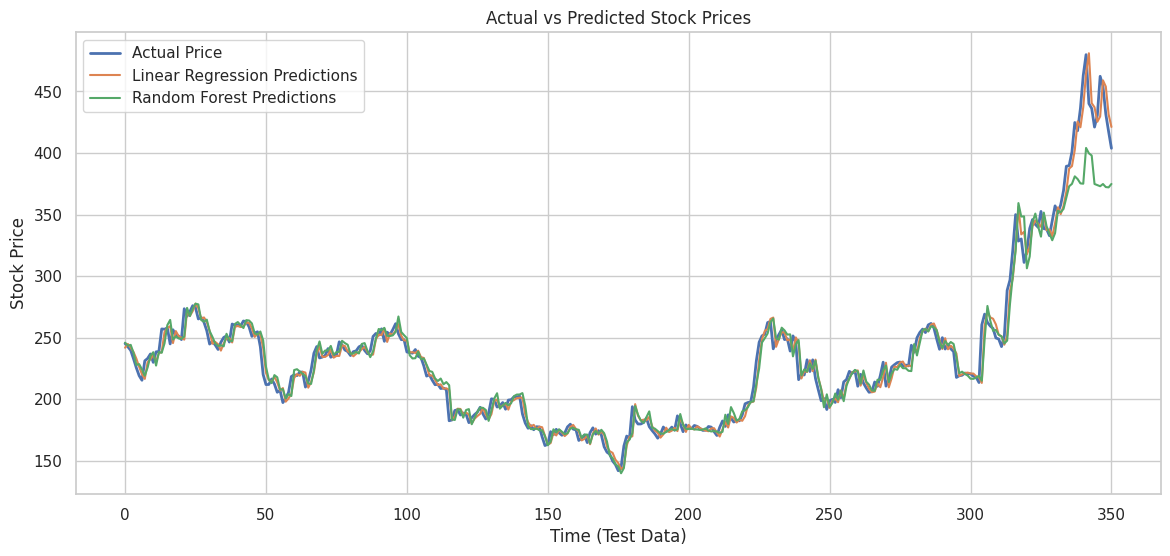

In [26]:
plt.figure(figsize=(14,6))

# Actual values
plt.plot(y_test.values, label="Actual Price", linewidth=2)

# Predictions
plt.plot(lr_pred, label="Linear Regression Predictions")
plt.plot(rf_pred, label="Random Forest Predictions")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time (Test Data)")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### 📊 Visualization Insights

From the plot, we can observe:

#### 🔹 Linear Regression:
- Follows overall trend smoothly
- Fails to capture sharp fluctuations
- Appears overly stable due to linear assumptions

#### 🔹 Random Forest:
- Captures more local variations
- Slightly noisier predictions
- Still struggles during high volatility periods

### ⚠️ Key Observation

Even though metrics were strong, neither model perfectly captures extreme market movements. This confirms that stock prices contain:
- High randomness
- Non-linear dynamics
- External influences not captured in the dataset

## 11. Feature Importance Analysis (Random Forest)

### 📌 Why This Step Matters

While prediction accuracy is important, interpretability is critical in financial modeling.

We need to understand:
- Which features influence stock price predictions the most
- Whether engineered features (lags, rolling stats) are actually useful
- How the model is making decisions

Random Forest provides built-in feature importance scores that help us interpret model behavior.

In [27]:
import pandas as pd

# Get feature importance from Random Forest
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

feature_importance_df

,Feature,Importance
0,Close,0.576171
3,Low,0.288689
2,High,0.101635
1,Open,0.012149
10,Rolling_Mean_10,0.009523
8,Rolling_Mean_5,0.005087
5,Close_Lag1,0.004298
6,Close_Lag2,0.000909
11,Rolling_Std_10,0.000624
4,Volume,0.000417


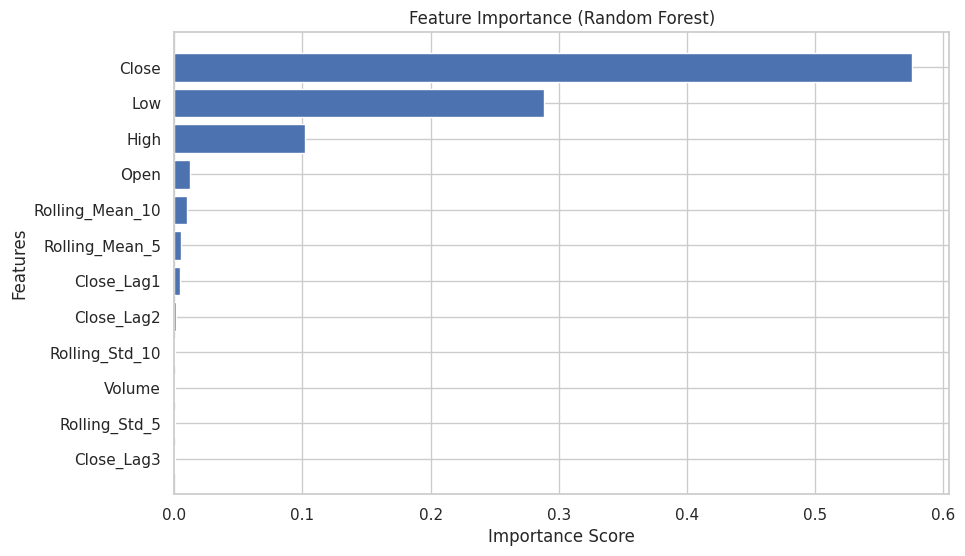

In [28]:
plt.figure(figsize=(10,6))

plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()

plt.show()

### 📊 Key Observations

From the feature importance results:

#### 🔹 1. Close Price Dominates (~57%)
The most important feature is the current closing price.

This indicates:
- Strong autocorrelation in stock prices
- The model heavily relies on recent observed price levels

#### 🔹 2. High and Low Prices Are Also Significant
- High (~10%)
- Low (~28%)

These features capture daily volatility range, which helps the model understand market movement boundaries.

#### 🔹 3. Engineered Features Have Low Importance
- Lag features
- Rolling statistics

These contribute very little compared to raw price features.

---

### ⚠️ Important Insight

Although we engineered advanced features, the model still primarily relies on raw price data.

This suggests that:
- Stock price movement is highly dependent on immediate market conditions
- Feature engineering alone may not fully capture market complexity

## 12. 📉 Residual Analysis (Error Diagnostics)

### 📌 Why Residual Analysis Matters

Model evaluation metrics like MAE and RMSE tell us how accurate the model is overall, but they do not explain *when* or *why* the model fails.

Residual analysis helps us understand:
- Where the model performs well
- Where it fails
- Whether errors are random or systematic
- How the model behaves during volatile market periods

In [29]:
# Residuals = Actual - Predicted (Random Forest chosen for analysis)
residuals = y_test.values - rf_pred

residuals[:10]

array([-0.65297058, -0.9642392 , -4.47180527, -4.79872498, -2.29129333,
       -9.37849716, -8.83202774, 12.11119919,  7.34456924,  1.69963287])

### 📌 What Are Residuals?

Residuals represent the difference between actual and predicted values.

- Positive residual → model underpredicted price
- Negative residual → model overpredicted price

Analyzing residuals helps us understand model bias and error distribution.

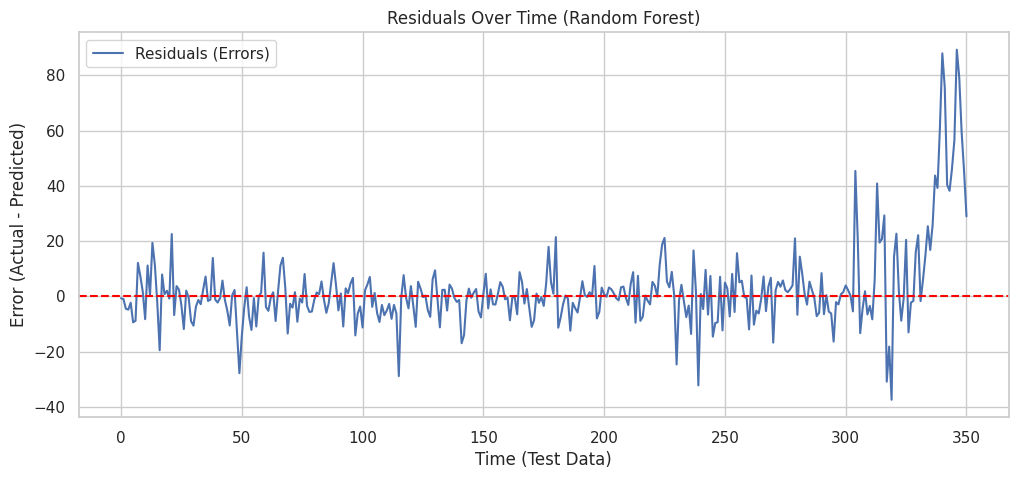

In [30]:
plt.figure(figsize=(12,5))

plt.plot(residuals, label="Residuals (Errors)")
plt.axhline(y=0, color='red', linestyle='--')

plt.title("Residuals Over Time (Random Forest)")
plt.xlabel("Time (Test Data)")
plt.ylabel("Error (Actual - Predicted)")
plt.legend()

plt.show()

### 📊 Residual Pattern Analysis

From the residual plot, we observe:

#### 🔹 1. Errors fluctuate around zero
This indicates that the model is not strongly biased toward overprediction or underprediction.

#### 🔹 2. Larger errors during volatile periods
Spikes in residuals correspond to sudden market movements, where the model struggles to adapt quickly.

#### 🔹 3. Stable periods show lower error
During calmer market phases, predictions are significantly more accurate.

---

### ⚠️ Key Insight

The model performs well in stable market conditions but struggles during high volatility periods. This is a common limitation of traditional machine learning models in financial forecasting.

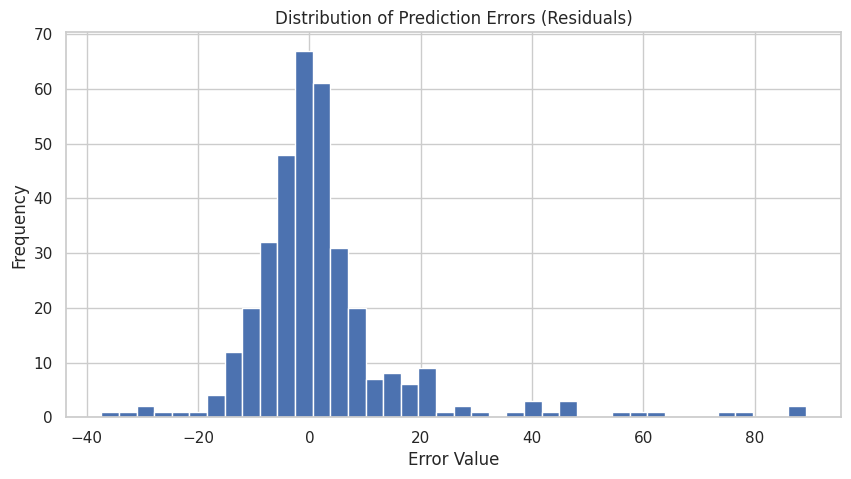

In [31]:
plt.figure(figsize=(10,5))

plt.hist(residuals, bins=40)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error Value")
plt.ylabel("Frequency")

plt.show()

### 📊 Error Distribution Analysis

The histogram shows how prediction errors are distributed.

#### 🔹 Ideal case:
- Symmetric distribution around zero
- Narrow spread

#### 🔹 Our model:
- Roughly centered around zero
- Some extreme outliers present

---

### ⚠️ Insight

The presence of outliers indicates that the model occasionally fails during sharp market movements, which is expected in financial time series data.

## 13. Final Conclusion

### 📌 Project Summary

In this project, we developed a machine learning pipeline to predict short-term stock prices using historical Tesla (TSLA) market data.

We followed a complete workflow:
- Data collection using yfinance
- Feature engineering (lag features + rolling statistics)
- Time-aware train-test splitting
- Model training (Linear Regression and Random Forest)
- Evaluation using regression metrics
- Feature importance analysis
- Residual diagnostics

---

### 📊 Key Results

- Linear Regression achieved high performance (R² ≈ 0.97), indicating strong linear relationships in short-term price movements.
- Random Forest provided slightly lower R² but captured more non-linear behavior.
- Feature importance revealed that raw price features dominate predictive power.

---

### 🧠 Key Insights

1. Stock prices exhibit strong short-term autocorrelation, making recent values highly predictive.
2. Engineered features (lags, rolling statistics) provide limited additional gain compared to raw price data.
3. Models perform significantly better during stable market conditions and struggle during high volatility periods.
4. High accuracy does not necessarily imply strong predictive power in real trading conditions.

---

### ⚠️ Important Limitation

Despite strong evaluation metrics, this model should not be interpreted as a trading system. Financial markets are influenced by external factors not included in this dataset, such as:

- News and sentiment
- Macroeconomic indicators
- Market events and shocks

Therefore, the model captures historical patterns but cannot fully account for real-world complexity.

---

### 📌 Final Takeaway

This project demonstrates that while machine learning can model short-term trends in financial data, stock markets remain highly stochastic and influenced by external variables beyond historical price patterns.

## 14. 🚀 Future Improvements

This project can be extended in several directions:

### 🔹 1. Deep Learning Models
- LSTM (Long Short-Term Memory networks)
- GRU-based architectures
These models are better suited for sequential dependencies.

### 🔹 2. Sentiment Analysis Integration
- Incorporate news headlines
- Twitter sentiment scoring
- Market sentiment indicators

### 🔹 3. Macro-Economic Features
- Interest rates
- Inflation indicators
- Market indices (S&P 500)

### 🔹 4. Advanced Time-Series Methods
- ARIMA / SARIMA models
- Transformer-based forecasting models

---

### 📌 Final Thought

Stock prediction is not just a machine learning problem — it is a complex system influenced by human behavior, economics, and global events.